## DATA PREPARING

In [79]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("innacampo/s-and-p-500-stocks-daily-historical-data-10-years")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 's-and-p-500-stocks-daily-historical-data-10-years' dataset.
Path to dataset files: /kaggle/input/s-and-p-500-stocks-daily-historical-data-10-years
Path to dataset files: /kaggle/input/s-and-p-500-stocks-daily-historical-data-10-years


In [80]:
# Directory path : /root/.cache/kagglehub/datasets/innacampo/s-and-p-500-stocks-daily-historical-data-10-years/versions/1
import pandas as pd
import os
directory = os.listdir(path)
print(directory)

['SP500_Data_10Y']


In [81]:
subdir = f"{path}/SP500_Data_10Y"


# Chọn 5 cổ phiếu để đưa vào rổ
selected_files =['ACGL.csv','FIS.csv','FITB.csv','IEX.csv','LOW.csv']
list_file=[]

# Danh sách tên cột
column_names = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
for file_name in selected_files:

    #Tạo đường dẫn đến từng file
    file_path = os.path.join(subdir, file_name)

    # Đọc file vào DataFrame
    df = pd.read_csv(file_path, skiprows=3, names=column_names, header=None)

    # Thêm cột Ticker để phẩn biệt data thuộc cổ phiếu nào
    df['ticker'] = file_name.replace('.csv','')

    # Thêm file vào danh sách
    list_file.append(df)

# Gộp danh sách các cột
data=pd.concat(list_file,ignore_index=True)

data.head(5)

,Date,Close,High,Low,Open,Volume,ticker
0,2015-12-21,22.086205,22.460225,21.965757,22.270044,897000,ACGL
1,2015-12-22,22.241516,22.285892,21.547361,22.212990,915900,ACGL
2,2015-12-23,22.311249,22.390491,22.193972,22.298571,644100,ACGL
3,2015-12-24,22.365133,22.479240,22.260534,22.273212,279000,ACGL
4,2015-12-28,22.485580,22.495090,21.766066,22.279552,566400,ACGL


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    12575 non-null  object 
 1   Close   12575 non-null  float64
 2   High    12575 non-null  float64
 3   Low     12575 non-null  float64
 4   Open    12575 non-null  float64
 5   Volume  12575 non-null  int64  
 6   ticker  12575 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 687.8+ KB


In [83]:
# Chuyển kiểu dữ liệu cột Date sang Datetime
data['Date']=pd.to_datetime(data['Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    12575 non-null  datetime64[ns]
 1   Close   12575 non-null  float64       
 2   High    12575 non-null  float64       
 3   Low     12575 non-null  float64       
 4   Open    12575 non-null  float64       
 5   Volume  12575 non-null  int64         
 6   ticker  12575 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 687.8+ KB


In [84]:
# Chuyển từ wide table sang long table
portfolio_data=data.pivot(index='Date',columns='ticker',values='Close')
portfolio_data.head(5)

ticker,ACGL,FIS,FITB,IEX,LOW
Date,,,,,
2015-12-21,22.086205,49.809185,14.037117,66.302826,62.293095
2015-12-22,22.241516,50.390102,14.178475,67.059456,62.517670
2015-12-23,22.311249,51.518318,14.461197,68.141632,63.349449
2015-12-24,22.365133,51.450947,14.503605,68.264816,63.449253
2015-12-28,22.485580,51.358341,14.454127,67.939293,63.582355


In [85]:
portfolio_data.shape

(2515, 5)

=> Bảng porfolio_data gồm 5 cột và 2515 dòng

In [86]:
portfolio_data.isnull().sum()

,0
ticker,
ACGL,0
FIS,0
FITB,0
IEX,0
LOW,0


=> Không có giá trị bị thiếu (No missing values)

## EDA (Exploratory Data Analysis)

# TỔNG QUAN DỮ LIỆU

In [87]:
portfolio_data.describe()

ticker,ACGL,FIS,FITB,IEX,LOW
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000
mean,48.224905,86.127338,26.586866,159.915687,147.354895
std,25.501485,24.482153,9.161577,47.354462,67.196852
min,20.567934,44.870720,9.271918,60.387039,52.947826
25%,28.816979,67.110020,19.965525,125.136860,82.284252
50%,37.579510,81.640884,23.788445,166.610001,151.332886
75%,70.304680,103.807030,33.567911,201.671219,209.582825
max,109.220207,139.710007,48.389999,239.840378,277.295776


Nhận xét :

1, Mã LOW có sự tăng trưởng mạnh mẽ nhất khi tăng từ đáy 53 USD lên đỉnh 277 USD

2, Mã IEX và LOW có độ lệch chuẩn (std) cao chứng tỏ sự biến động mạnh của 2 mã này đi kèm với rủi ro biến động cao

3, Giá trung bình của FITB là thấp nhất ; IEX và LOW là cao nhất

# VẼ BIỂU ĐỒ LỢI NHUẬN TÍCH LUỸ

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

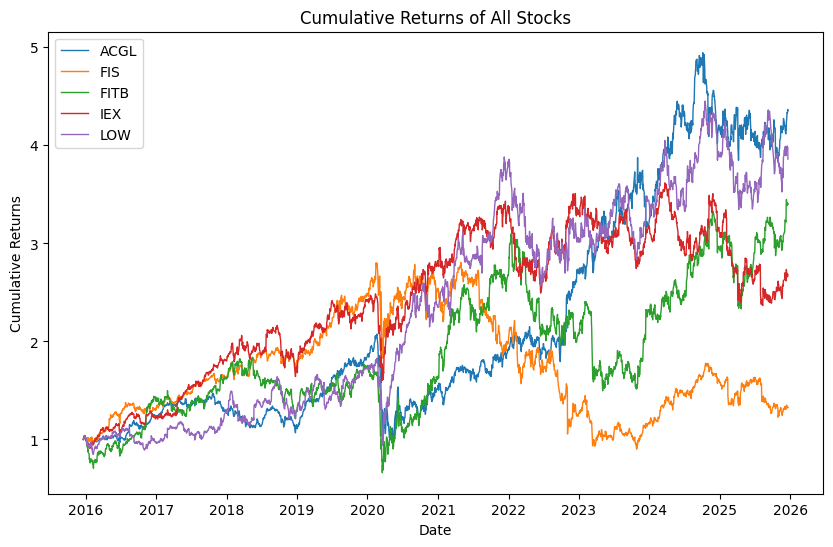

In [89]:
plt.figure(figsize=(10, 6))

# Tính lợi nhuận tích luỹ = Tất cả các dòng / Dòng đầu tiên
cumulative_returns= portfolio_data/portfolio_data.iloc[0]
for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column], label=column,linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Cumulative Returns of All Stocks')
plt.legend()
plt.show()



Nhận xét:

1, ACGL bứt phá mạnh mẽ từ sau 2021 với lợi nhuận tích luỹ đã tăng gấp 4,5 lần vào thời điểm này và đỉnh cao là gấp 5 lần vào năm 2024 . LOW cũng có mức tăng trưởng ấn tượng với con số từ 3,5 đến 4,3 lần.

2, ITEX có mức tăng trưởng bền vững với con số từ 2,5 đến 3,5 lần ; với FITB là từ 2 đến 3 lần

3, FIS là mã có ít sự bứt phá nhất khi lợi nhuận tích luỹ hiện tại chỉ khoảng 1,2 lần và cao nhất cũng chỉ là 2,5 lần



# VẼ BIỂU ĐỒ PHÂN TÍCH GIÁ TRỊ NGOẠI LAI (OUTLIERS)

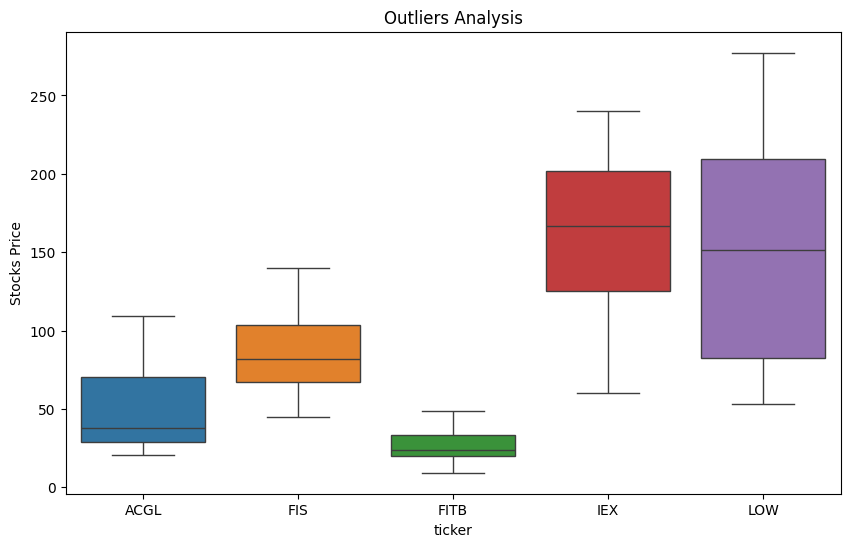

In [90]:
# Phân tích các outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=portfolio_data)
plt.title('Outliers Analysis')
plt.ylabel('Stocks Price')
plt.show()

Nhận xét:

1, Dữ liệu không có giá trị ngoại lai (Outliers) => Không có các phiên giá tăng hay giảm về mức vô lý ( Dữ liệu không bị sai và lỗi)

2,Biến động nằm trong tầm kiểm soát và không phải do các biến động tức thời



# VẼ BIỂU ĐỒ HIỆP PHƯƠNG SAI VÀ ĐỘ TƯƠNG QUAN GIỮA CÁC CỔ PHIẾU

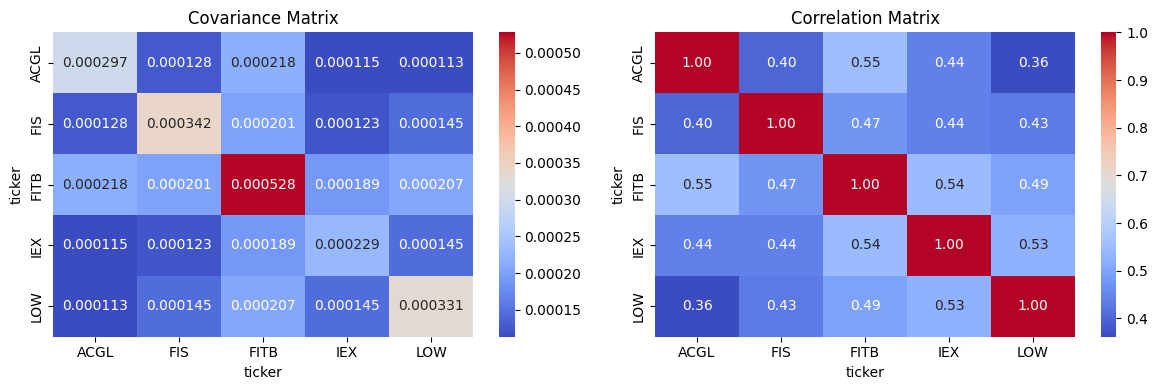

In [91]:
# Tạo ma trận hiệp phương sai theo lợi nhuận hàng ngày
cov_matrix= portfolio_data.pct_change().dropna().cov()

# Tạo ma trận tương quan theo lợi nhuận hàng ngày
corr_matrix= portfolio_data.pct_change().dropna().corr()

# Vẽ biểu đồ
fig,ax = plt.subplots(1,2,figsize=(12,4))

sns.heatmap(cov_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.6f',
            ax=ax[0]
            )
ax[0].set_title('Covariance Matrix')

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            ax=ax[1]
            )
ax[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

Nhận xét:

1, Các hệ số tương quan nằm trong khoảng từ 0.36 đến 0.56 => Đây là mức tương quan trung bình và rất phù hợp để đa dạng hoá danh mục đầu tư , các cổ phiếu không quá phụ thuộc nhau vào ngắn hạn

2, ACGL và LOW có hệ số tương quan là 0.36 dựa trên lợi nhuận hàng ngày cho thấy mô hình Makorwitz có thể phân bổ đáng kể vào cặp đôi này để tối ưu Sharpe Ratio

## FEATURE ENGINEERING

In [92]:
# Tính daily returns
daily_returns = portfolio_data.pct_change().dropna()
daily_returns.head(5)

ticker,ACGL,FIS,FITB,IEX,LOW
Date,,,,,
2015-12-22,0.007032,0.011663,0.010070,0.011412,0.003605
2015-12-23,0.003135,0.022390,0.019940,0.016138,0.013305
2015-12-24,0.002415,-0.001308,0.002933,0.001808,0.001575
2015-12-28,0.005385,-0.001800,-0.003411,-0.004769,0.002098
2015-12-29,0.004229,0.009672,0.007874,0.006345,0.009027


Năm hoá:

Lợi nhuận theo năm = Lợi nhuận theo ngày * 252

Độ lệch chuẩn theo năm = Độ lệch chuẩn theo ngày * sqrt(252)

( Giả sử có 252 phiên giao dịch trong năm )


In [93]:
daily_mean = daily_returns.mean()
daily_std = daily_returns.std()

# Năm hoá daily returns và std của nó
annual_mean = daily_mean * 252
annual_volatility = daily_std * np.sqrt(252)

# Tính Sharpe Ratio = Lợi nhuận theo năm / Rủi ro theo năm
sharpe_ratio = annual_mean / annual_volatility

# Bảng so sánh
comparison_table = pd.DataFrame({
    'Annual Mean': annual_mean,
    'Annual Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio
})

comparison_table.sort_values(by='Sharpe Ratio',ascending=False)
comparison_table




,Annual Mean,Annual Volatility,Sharpe Ratio
ticker,,,
ACGL,0.185167,0.273600,0.676782
FIS,0.072559,0.293507,0.247214
FITB,0.189763,0.364731,0.520281
IEX,0.127845,0.240082,0.532507
LOW,0.177787,0.289000,0.615181


Nhận xét:

1, ACGL có Sharpe Ratio cao nhất và là cổ có hiệu quả tốt nhất danh mục

2, FITB tuy có lợi nhuận trung bình hằng năm cao nhất nhưng do biến động quá cao nên làm Sharpe Ratio giảm đáng kể

3, IEX có lợi nhuận mức trung bình 12,78% nhưng lại có độ biến động thấp nhất trong 5 cổ phiếu và sẽ là sự lựa chọn an toàn nhất trong rổ khi thị trường biến động

## MODELLING

# MÔ PHỎNG 20000 KỊCH BẢN CHIA DANH MỤC KHÁC NHAU (MONTE CARLO)

In [94]:
# Định nghĩa các tham số đầu vào
exp_returns = annual_mean
cov_matrix = daily_returns.cov()*252   # Ma trận hiệp phương sai
num_assets = len(exp_returns)     # Số lượng mã cổ phiếu
num_simulations = 20000           # Số lượng kịch bản xây dựng

# Ma trận lưu kết quả
results=np.zeros((num_assets+3,num_simulations))

for i in range(num_simulations):
    # Tạo trọng số ngẫu nhiên tương ứng với tỷ lệ nắm giữ của 5 cổ phiếu
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    # Tính lợi nhuận của danh mục
    portfolio_return = np.sum(exp_returns * weights)

    # Tính rủi ro danh mục
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    #Lưu kết quả
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = results[0,i] / results[1,i] # Sharpe Ratio
    for j in range(num_assets):
        results[j+3,i]=weights[j]

columns=['Returns','Volatility','Sharpe Ratio']+[ticker for ticker in exp_returns.index]
results_df = pd.DataFrame(results.T,columns=columns)
results_df.head(5)



,Returns,Volatility,Sharpe Ratio,ACGL,FIS,FITB,IEX,LOW
0,0.134980,0.236858,0.569875,0.147759,0.409787,0.236481,0.072261,0.133712
1,0.172443,0.235179,0.733244,0.443402,0.079415,0.235302,0.061619,0.180262
2,0.161875,0.223983,0.722711,0.182146,0.086800,0.171605,0.203790,0.355659
3,0.146713,0.213532,0.687076,0.283845,0.258568,0.026075,0.125605,0.305907
4,0.131066,0.210009,0.624096,0.219615,0.330285,0.023933,0.277793,0.148374


In [95]:
# Tìm 2 kịch bản chia portfolio đem lại Sharpe Ratio cao nhất và Volatility thấp nhất
max_sharpe_ratio = results_df.iloc[results_df['Sharpe Ratio'].idxmax()]
min_vol_ratio = results_df.iloc[results_df['Volatility'].idxmin()]

print(max_sharpe_ratio,min_vol_ratio,sep='\n\n')

Returns         0.173290
Volatility      0.220031
Sharpe Ratio    0.787569
ACGL            0.431211
FIS             0.003395
FITB            0.040562
IEX             0.156352
LOW             0.368480
Name: 14956, dtype: float64

Returns         0.142198
Volatility      0.204712
Sharpe Ratio    0.694626
ACGL            0.272553
FIS             0.175433
FITB            0.001502
IEX             0.383605
LOW             0.166908
Name: 6408, dtype: float64


# VẼ ĐƯỜNG BIÊN HIỆU QUẢ

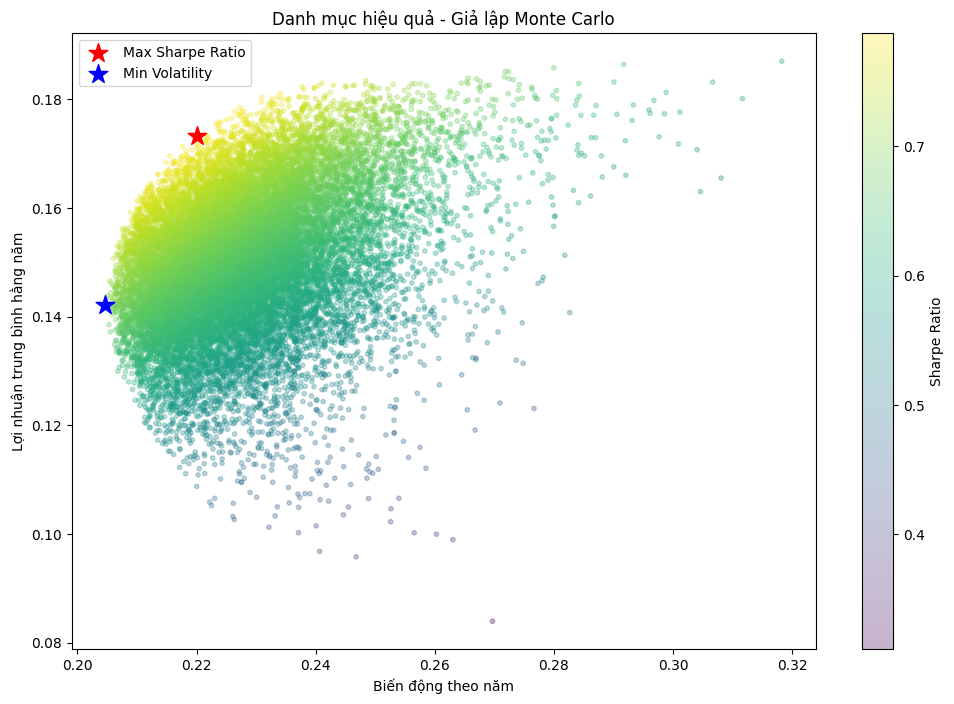

In [96]:
plt.figure(figsize=(12, 8))
# Vẽ tất cả các danh mục mô phỏng
plt.scatter(results_df.Volatility, results_df.Returns, c=results_df['Sharpe Ratio'], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Đánh dấu danh mục có Max Sharpe (Sao đỏ)
plt.scatter(max_sharpe_ratio.Volatility, max_sharpe_ratio.Returns, color='r', marker='*', s=200, label='Max Sharpe Ratio')

# Đánh dấu danh mục có Min Volatility (Sao xanh)
plt.scatter(min_vol_ratio.Volatility, min_vol_ratio.Returns, color='b', marker='*', s=200, label='Min Volatility')

plt.title('Danh mục hiệu quả - Giả lập Monte Carlo')
plt.xlabel('Biến động theo năm')
plt.ylabel('Lợi nhuận trung bình hằng năm')
plt.legend()
plt.show()

Nhận xét:

1, Ngôi sao đỏ chính là vùng đầu tư thông minh nhất dựa trên chỉ số Sharpe Ratio đem lại mức bù đắp lợi nhuận lớn nhất dựa trên mỗi đơn vị rủi ro (18%)

2, Ngôi sao xanh chính là vùng an toàn nhất với độ biến động thấp nhất nhưng bù lại lợi nhuận đem lại chỉ ở mức 14%

3, Đường cánh cung được nối từ sao đỏ với sao xanh chính là vùng đầu tư đối với rổ cố phiếu này khi với mỗi điểm ở cánh cung này thì không thể có điểm có lợi nhuận cao hơn mà rủi ro không tăng

## SO SÁNH GIỮA VIỆC SỬ DỤNG BI-LSTM VÀ XGBOOST ĐỂ DỰ ĐOÁN XU HƯỚNG TĂNG/GIẢM VÀO NGÀY TIẾP THEO ( ACGL )

# 1, FEATURE ENGINEERING

In [97]:
data=data[data['ticker']=='ACGL']
data.head(5)

,Date,Close,High,Low,Open,Volume,ticker
0,2015-12-21,22.086205,22.460225,21.965757,22.270044,897000,ACGL
1,2015-12-22,22.241516,22.285892,21.547361,22.212990,915900,ACGL
2,2015-12-23,22.311249,22.390491,22.193972,22.298571,644100,ACGL
3,2015-12-24,22.365133,22.479240,22.260534,22.273212,279000,ACGL
4,2015-12-28,22.485580,22.495090,21.766066,22.279552,566400,ACGL


In [98]:
!pip install pandas_ta

In [99]:
import pandas_ta as ta

# Return
daily_return=data.Close.pct_change()
data['Log_Daily_Return'] =np.log(1+daily_return)
data['Return']=daily_return

lag_log_return=data['Log_Daily_Return'].shift(1)
data['Lag_Log_Return']=lag_log_return

# Volume
data['Volume_Change'] = data.groupby('ticker').Volume.pct_change()
volume_ma_20 =data.groupby('ticker').Volume.transform(lambda x : x.rolling(20).mean())
data['Volume_Change_MA20'] = data.Volume / volume_ma_20

# RSI
data['RSI_14'] = data.groupby('ticker').Close.transform(lambda x : ta.rsi(x,length=14))
data['RSI_14_MA60']=data.groupby('ticker')['RSI_14'].transform(lambda x : x.rolling(60).mean())

# EMA
data['EMA_20'] = data.groupby('ticker').Close.transform(lambda x :x.ewm(span=20,adjust=False).mean())
data['EMA_Cross'] = data['EMA_20']-data.groupby('ticker').Close.transform(lambda x :x.ewm(span=60,adjust=False).mean())
data['Dist_EMA_60'] = (data['Close'] - data.groupby('ticker').Close.transform(lambda x :x.ewm(span=60,adjust=False).mean())) / data.groupby('ticker').Close.transform(lambda x :x.ewm(span=60,adjust=False).mean())

# Volatility
data['Rolling_Std_20'] = data.groupby('ticker').Close.transform(lambda x : x.rolling(20).std())
data['H_L_Spread']= (data['High'] - data['Low']) / data['Close']

# Tạo nhãn : 1 nếu ngày mai tăng còn 0 nếu ngày mai giảm
data['Target_Class']=np.where(data['Log_Daily_Return'].shift(-1)>0 ,1,0 )


data.dropna(inplace=True)
data.head(5)

,Date,Close,High,Low,Open,Volume,ticker,Log_Daily_Return,Return,Lag_Log_Return,Volume_Change,Volume_Change_MA20,RSI_14,RSI_14_MA60,EMA_20,EMA_Cross,Dist_EMA_60,Rolling_Std_20,H_L_Spread,Target_Class
60,2016-03-18,22.241516,22.374643,22.073524,22.238348,951900,ACGL,0.001283,0.001284,0.006873,0.065123,0.991981,61.670200,59.484668,21.932549,0.157825,0.021437,0.214727,0.013539,1
61,2016-03-21,22.333437,22.409509,21.683655,22.165443,490500,ACGL,0.004124,0.004133,0.001283,-0.484715,0.521673,63.620527,58.878344,21.970729,0.177686,0.024797,0.231709,0.032501,1
62,2016-03-22,22.346115,22.542634,22.095713,22.209820,1145100,ACGL,0.000568,0.000568,0.004124,1.334557,1.195877,63.893414,58.276567,22.006480,0.195304,0.024526,0.234364,0.020000,1
63,2016-03-23,22.349283,22.504599,22.174953,22.323928,536400,ACGL,0.000142,0.000142,0.000568,-0.531569,0.574836,63.966153,57.676003,22.039128,0.210309,0.023843,0.244561,0.014750,0
64,2016-03-24,21.972095,22.466563,21.886514,22.308079,813900,ACGL,-0.017021,-0.016877,0.000142,0.517338,0.900910,50.835418,56.856594,22.032744,0.199227,0.006347,0.243362,0.026399,1


# 2, XÂY DỰNG VÀ ĐÁNH GIÁ MÔ HÌNH HỌC SÂU (BI-LSTM)

In [100]:
from sklearn.preprocessing import MinMaxScaler,LabelEncoder



features=['Volume_Change','Volume_Change_MA20','RSI_14','RSI_14_MA60','EMA_20','EMA_Cross','Rolling_Std_20','H_L_Spread']


# Chia dữ liệu thành train và test
final_data=data.dropna().copy()
train_size= int(len(final_data)*0.8)
train_data=final_data.iloc[:train_size]
test_data=final_data.iloc[train_size:]

# Scale dữ liệu về khoảng 0,1
scaler_x = MinMaxScaler(feature_range=(0,1))

train_data[features] = scaler_x.fit_transform(train_data[features])
test_data[features] = scaler_x.transform(test_data[features])

# Tạo cấu trúc chuỗi cho LSTM
def create_sequences(df,length):
    x = []
    y = []
    for ticker in df.ticker.unique():
        # Lấy dữ liệu riêng cho từng mã cố phiếu
        ticker_df = df[df['ticker'] == ticker]
        ticker_values = ticker_df[features + ['Target_Class']].values
        for i in range(length ,len(ticker_values)):
            x.append(ticker_values[i-length:i, : -1])
            y.append(ticker_values[i,-1])
    return np.array(x),np.array(y)

x_train ,  y_train = create_sequences(train_data,60)
x_test  ,  y_test  = create_sequences(test_data,60)


In [101]:
x_train.shape

(1904, 60, 8)

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout,BatchNormalization,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

model = Sequential()

# Layer 1
model.add(Bidirectional(LSTM(units=20, return_sequences=True,kernel_regularizer=regularizers.l2(0.01), input_shape=(x_train.shape[1], x_train.shape[2]))))
model.add(Dropout(0.3))
model.add(BatchNormalization())

# Layer2
model.add(Bidirectional(LSTM(units=32)))
model.add(Dropout(0.35))

model.add(Dense(units=1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [103]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [104]:
from sklearn.utils import class_weight

# Tính toán trọng số dựa trên phân phối thực tế của y_train
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

early_stopping = EarlyStopping (monitor= 'val_loss',
                                patience=10,
                                restore_best_weights=True
                                )
model.fit(x_train,y_train,epochs = 50,batch_size = 32, callbacks=early_stopping,validation_split=0.1,verbose=1,shuffle=False,class_weight=class_weights_dict)

Epoch 1/50


54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.4950 - loss: 0.9297 - val_accuracy: 0.5654 - val_loss: 0.8539
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.4991 - loss: 0.8324 - val_accuracy: 0.5654 - val_loss: 0.7877
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.5143 - loss: 0.7749 - val_accuracy: 0.5550 - val_loss: 0.7485
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.4880 - loss: 0.7475 - val_accuracy: 0.5654 - val_loss: 0.7227
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5114 - loss: 0.7290 - val_accuracy: 0.5654 - val_loss: 0.7102
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5336 - loss: 0.7147 - val_accuracy: 0.5654 - val_loss: 0.7044
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.5201 - loss: 0.7110 - val_accuracy: 0.5654 - val_loss: 0.7007
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5336 - loss: 0.7064 - val_accuracy: 0.5759 - val_loss: 

# VẼ BIỂU ĐỒ SO SÁNH THỰC TẾ VÀ DỰ ĐOÁN

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


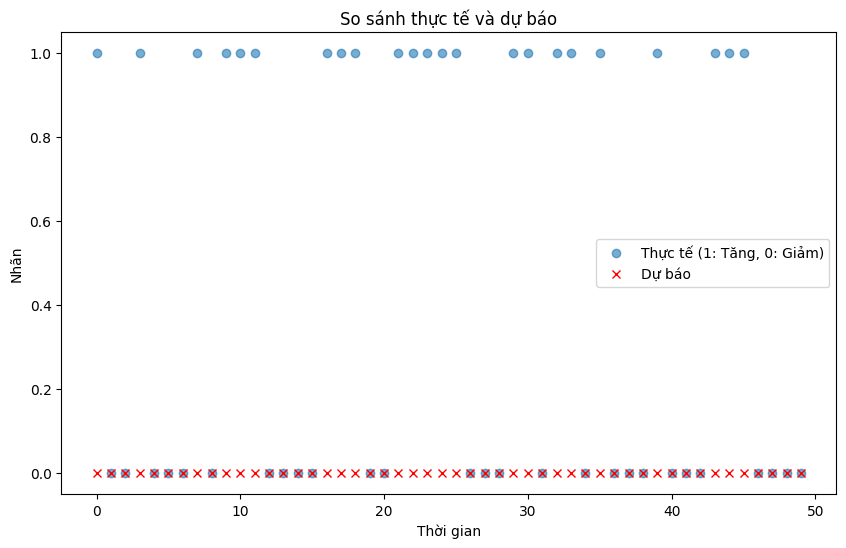

In [105]:
import matplotlib.pyplot as plt

# 1. Lấy xác suất dự báo từ mô hình
y_pred_probs = model.predict(x_test)

# 2. Chuyển xác suất thành nhãn 0/1
y_pred_labels = (y_pred_probs > np.median(y_pred_probs)).astype(int).flatten()

# 3. Vẽ biểu đồ so sánh 50 điểm dữ liệu đầu tiên
plt.figure(figsize=(10, 6))
plt.plot(y_test[:50], label='Thực tế (1: Tăng, 0: Giảm)', marker='o', linestyle='', alpha=0.6)
plt.plot(y_pred_labels[:50], label='Dự báo', marker='x', linestyle='', color='red')
plt.xlabel('Thời gian')
plt.ylabel('Nhãn')
plt.title('So sánh thực tế và dự báo')
plt.legend()
plt.show()

# KIỂM TRA PHÂN PHỐI GIỮA CÁC NHÃN

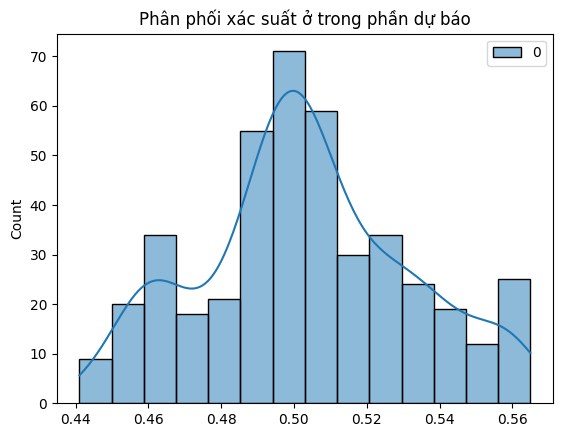

0    216
1    215
Name: count, dtype: int64


In [106]:
# Kiểm tra giá trị xác suất thực tế mà model trả về
sns.histplot(y_pred_probs, kde=True)
plt.title("Phân phối xác suất ở trong phần dự báo")
plt.show()

# Đếm số lượng nhãn mỗi loại
print(pd.Series(y_pred_labels).value_counts())

# VẼ BIỂU ĐỒ SO SÁNH LỢI NHUẬN GIỮA VIỆC SỬ DỤNG BI-LSTM VÀ CHIẾN THUẬT MUA RỒI GIỮ

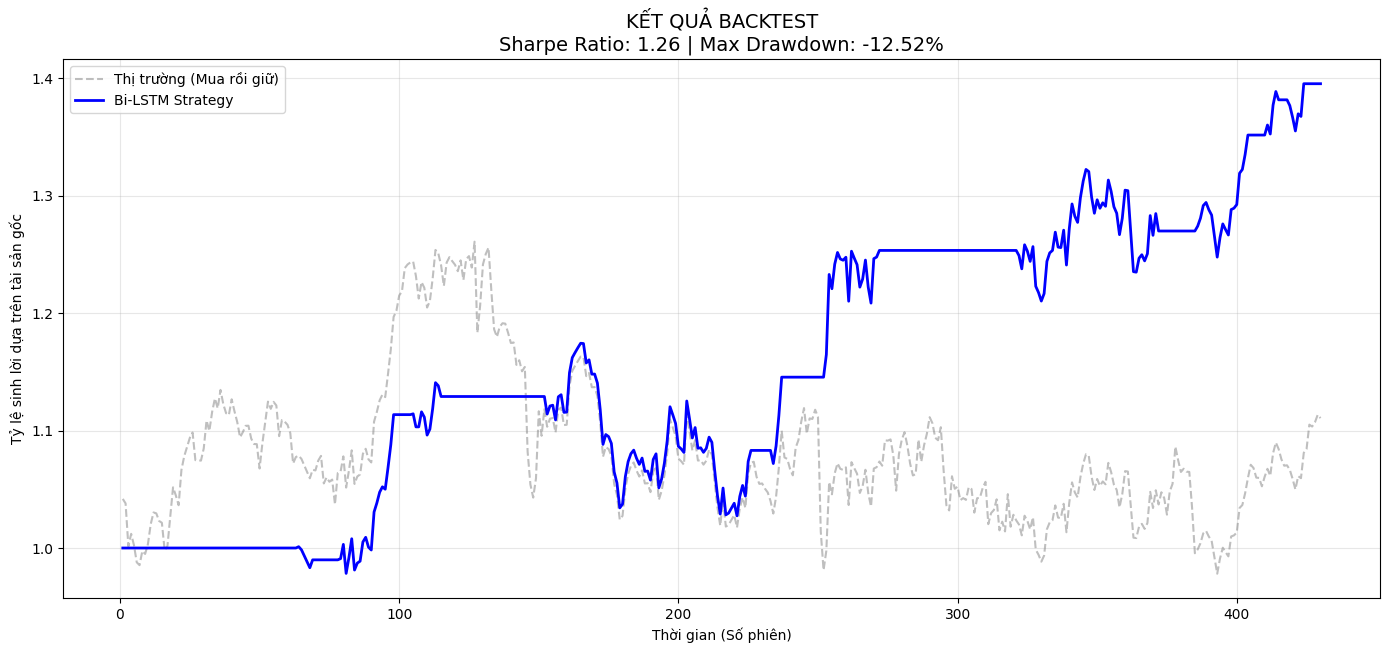

Mức sinh lời của thị trường: 11.06%
Mức sinh lời của chiến thuật: 39.55%


In [107]:

# Tạo bảng
y_test_returns = test_data['Log_Daily_Return'].values[60:]
results = pd.DataFrame({
    'Actual_Return': y_test_returns.flatten(),
    'Prob_Up': y_pred_probs.flatten()
})

# Sử dụng ngưỡng
results['Signal'] = (results['Prob_Up'] > np.median(results['Prob_Up'])).astype(int)

# Tín hiệu ở ngày hôm nay là cơ sở cho ngày mai quyết định mua hay đứng ngoài (1 sẽ mua và tính lợi nhuận, 0 sẽ đứng ngoài quan sát)
results['Strategy_Return'] = results['Signal'].shift(1) * results['Actual_Return']
results.dropna(inplace=True)

# Tính lợi nhuận cộng dồn (quy đổi từ Log Return sang tỷ lệ phần trăm)
results['Market_Cum'] = results['Actual_Return'].cumsum().apply(np.exp)
results['Strategy_Cum'] = results['Strategy_Return'].cumsum().apply(np.exp)

# Tính sharpe ratio
daily_rf = 0 # Lãi suất phi rủi ro coi như = 0
sharpe = np.sqrt(252) * (results['Strategy_Return'].mean() - daily_rf) / results['Strategy_Return'].std()

# Max Drawdown (Mức sụt giảm tối đa từ đỉnh)
peak = results['Strategy_Cum'].cummax()
drawdown = (results['Strategy_Cum'] - peak) / peak
max_drawdown = drawdown.min()

# Vẽ biểu đồ
plt.figure(figsize=(17, 7))
plt.plot(results['Market_Cum'], label='Thị trường (Mua rồi giữ)', color='gray', alpha=0.5, linestyle='--')
plt.plot(results['Strategy_Cum'], label='Bi-LSTM Strategy', color='blue', linewidth=2)

plt.title(f'KẾT QUẢ BACKTEST\nSharpe Ratio: {sharpe:.2f} | Max Drawdown: {max_drawdown*100:.2f}%', fontsize=14)
plt.xlabel('Thời gian (Số phiên)')
plt.ylabel('Tỷ lệ sinh lời dựa trên tài sản gốc')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mức sinh lời của thị trường: {(results['Market_Cum'].iloc[-1]-1)*100:.2f}%")
print(f"Mức sinh lời của chiến thuật: {(results['Strategy_Cum'].iloc[-1]-1)*100:.2f}%")

## 3,XÂY DỰNG VÀ ĐÁNH GIÁ MÔ HÌNH HỌC MÁY (XGBOOSTCLASSIFIER)

In [108]:
!pip install lazypredict

# THỬ NGHIỆM TRÊN NHIỀU MÔ HÌNH KHÁC NHAU

In [109]:
from lazypredict.Supervised import LazyClassifier

features.append('Lag_Log_Return')


# Sử dụng dữ liệu đã chia
X_train_ml = train_data[features]
y_train_ml = train_data['Target_Class']
X_test_ml = test_data[features]
y_test_ml = test_data['Target_Class']

# Thử trên nhiều mô hình classification
clf= LazyClassifier(verbose = 0,ignore_warnings=True,custom_metric=None)
models , predictions = clf.fit(X_train_ml,X_test_ml,y_train_ml,y_test_ml)

#Đưa ra kết quả
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
BaggingClassifier,0.539715,0.543169,0.533539,0.531993,0.546899,0.539715,0.301339
AdaBoostClassifier,0.543788,0.537317,0.537043,0.514426,0.548838,0.543788,0.317428
NuSVC,0.525458,0.532518,0.539251,0.489741,0.546282,0.525458,1.050903
SGDClassifier,0.527495,0.517990,0.512735,0.456685,0.536853,0.527495,0.043059
Perceptron,0.505092,0.516454,0.549628,0.395255,0.563853,0.505092,0.025750
KNeighborsClassifier,0.515275,0.511589,0.528400,0.505702,0.512817,0.515275,0.063496
ExtraTreeClassifier,0.505092,0.508900,0.508900,0.494800,0.510117,0.505092,0.028981
RandomForestClassifier,0.509165,0.508767,0.503429,0.509136,0.509112,0.509165,1.154815
NearestCentroid,0.509165,0.504234,0.535034,0.491502,0.505216,0.509165,0.034690


In [111]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Khởi tạo mô hình với các tham số chống Overfitting
xgb_model = XGBClassifier(
    n_estimators=1000,         # Số lượng cây
    learning_rate=0.05,       # Tốc độ học
    max_depth=6,              # Độ sâu tối đa mỗi cây
    subsample=0.8,            # Mỗi cây sẽ chỉ được thấy 80% dữ liệu ngẫu nhiên
    colsample_bytree=0.8,     # Mỗi cây sẽ chỉ được thấy 80% features
    eval_metric='logloss',    # Đo lường sai số
    random_state=42           # Để các lần chạy kết quả giống nhau
)


# Huấn luyện
xgb_model.fit(X_train_ml, y_train_ml)

# Dự báo xác suất
y_pred_probs_ml = xgb_model.predict_proba(X_test_ml)[:, 1]

# Dùng ngưỡng Median
threshold_ml = np.median(y_pred_probs_ml)
y_pred_labels_ml = (y_pred_probs_ml > threshold_ml).astype(int)

print(classification_report(y_test_ml, y_pred_labels_ml))

              precision    recall  f1-score   support

           0       0.50      0.51      0.51       239
           1       0.53      0.51      0.52       252

    accuracy                           0.51       491
   macro avg       0.51      0.51      0.51       491
weighted avg       0.51      0.51      0.51       491



# VẼ BIỂU ĐỒ PHÂN PHỐI NHÃN

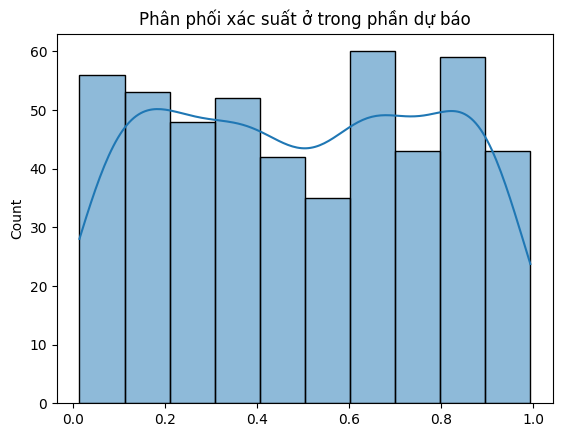

0    246
1    245
Name: count, dtype: int64


In [112]:
sns.histplot(y_pred_probs_ml, kde=True)
plt.title("Phân phối xác suất ở trong phần dự báo")
plt.show()

# Đếm số lượng từng nhãn
print(pd.Series(y_pred_labels_ml).value_counts())

# VẼ BIỂU ĐỒ SO SÁNH MỨC ĐỘ QUAN TRỌNG CÁC FEATURES

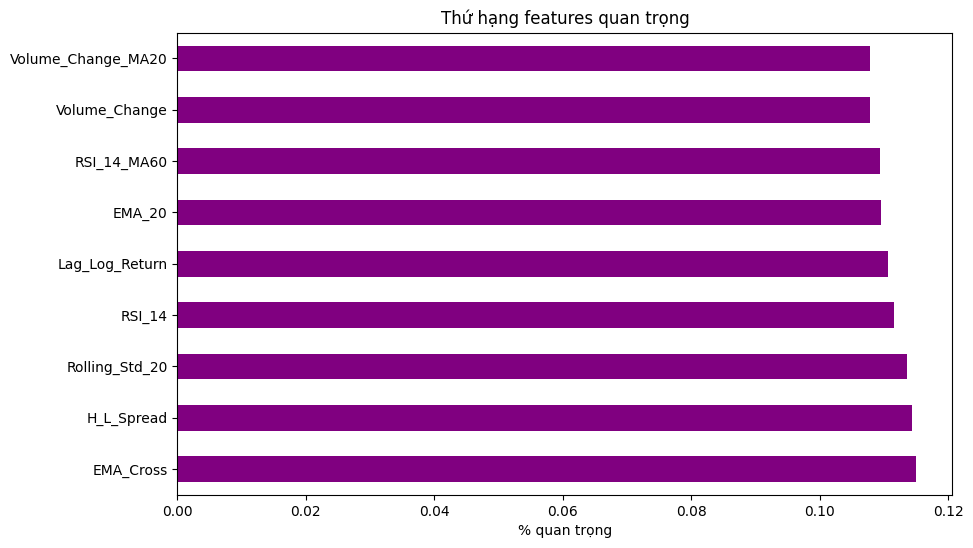

In [113]:
feature_importance = pd.Series(xgb_model.feature_importances_,index=features)

# Sắp xếp các features theo độ quan trọng
feature_importance.nlargest(10).plot(kind='barh',figsize=(10,6),color='purple')
plt.title('Thứ hạng features quan trọng')
plt.xlabel('% quan trọng')
plt.show()

CÁC FEATURES CÓ ĐÓNG GÓP GẦN NHƯ TƯƠNG ĐƯƠNG NHAU

# VẼ BIỂU ĐỒ SO SÁNH LỢI NHUẬN GIỮA VIỆC SỬ DỤNG XGBOOST VÀ CHIẾN THUẬT MUA RỒI GIỮ

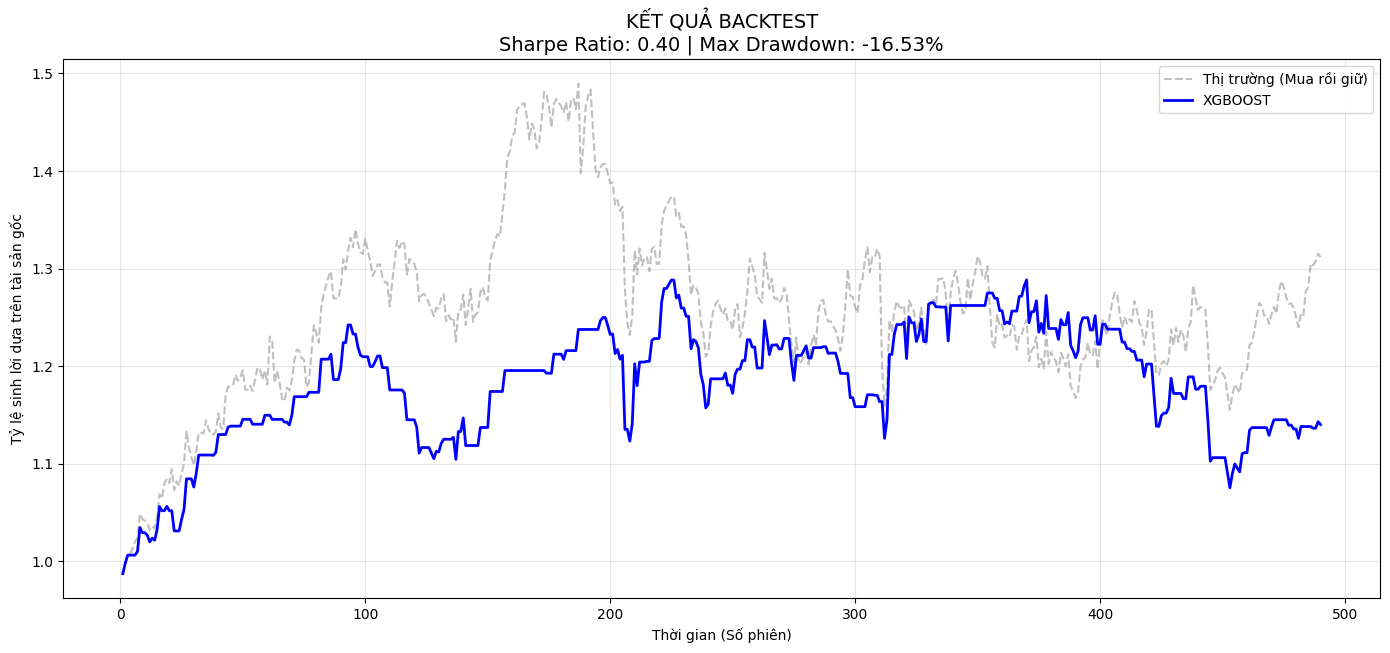

Mức sinh lời của thị trường: 31.18%
Mức sinh lời của chiến thuật: 14.02%


In [114]:
y_test_ml_returns = test_data['Log_Daily_Return'].values[len(test_data) - len(y_pred_probs_ml) :]
res = pd.DataFrame({
    'Actual_Return': y_test_ml_returns.flatten(),
    'Prob_Up': y_pred_probs_ml.flatten()
})

# Sử dụng ngưỡng là median để tạo tín hiệu mua hay đứng ngoài
res['Signal'] = (res['Prob_Up'] > np.median(res['Prob_Up'])).astype(int)

# Tín hiệu ngày hôm qua là cơ sở cho quyết định ngày hôm nay
res['Strategy_Return'] = res['Signal'].shift(1) * res['Actual_Return']
res.dropna(inplace=True)

# Tính lợi nhuận cộng dồn (quy đổi từ Log Return sang tỷ lệ phần trăm)
res['Market_Cum'] = res['Actual_Return'].cumsum().apply(np.exp)
res['Strategy_Cum'] = res['Strategy_Return'].cumsum().apply(np.exp)

# Tính sharpe ratio
daily_rf = 0 # Lãi suất phi rủi ro coi như = 0
sharpe = np.sqrt(252) * (res['Strategy_Return'].mean() - daily_rf) / res['Strategy_Return'].std()

# Max Drawdown (Mức sụt giảm tối đa từ đỉnh)
peak = res['Strategy_Cum'].cummax()
drawdown = (res['Strategy_Cum'] - peak) / peak
max_drawdown = drawdown.min()

# Vẽ biểu đồ
plt.figure(figsize=(17, 7))
plt.plot(res['Market_Cum'], label='Thị trường (Mua rồi giữ)', color='gray', alpha=0.5, linestyle='--')
plt.plot(res['Strategy_Cum'], label='XGBOOST', color='blue', linewidth=2)

plt.title(f'KẾT QUẢ BACKTEST\nSharpe Ratio: {sharpe:.2f} | Max Drawdown: {max_drawdown*100:.2f}%', fontsize=14)
plt.xlabel('Thời gian (Số phiên)')
plt.ylabel('Tỷ lệ sinh lời dựa trên tài sản gốc')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mức sinh lời của thị trường: {(res['Market_Cum'].iloc[-1]-1)*100:.2f}%")
print(f"Mức sinh lời của chiến thuật: {(res['Strategy_Cum'].iloc[-1]-1)*100:.2f}%")



## 4,KẾT LUẬN

Mô hình Bi-LSTM: Nhờ vào kiến trúc mạng nơ-ron hồi quy hai chiều, mô hình có khả năng khai thác tối ưu tính phụ thuộc thời gian (time-dependency) và các mẫu hình phi tuyến tính phức tạp trong dữ liệu lịch sử. Khả năng "ghi nhớ" dài hạn giúp Bi-LSTM bắt kịp các điểm đảo chiều xu hướng một cách khá nhạy bén với minh chứng là accuaracy của tập val lên đến hơn 57%.Tuy nhiên ,do quy mô dữ liệu quá nhỏ nên mô hình rất dễ bị overfitting và đây cũng không phải là cách tiếp cận tối ưu nhất.

Mô hình XGBoost: Là một thuật toán mạnh mẽ dựa trên Boosting cây quyết định, nhưng đối với dữ liệu chuỗi thời gian tài chính có độ nhiễu cao, XGBoost dễ rơi vào tình trạng quá khớp (overfitting) hoặc phản ứng chậm với các biến động ngắn hạn nếu thiếu các đặc trưng kỹ thuật chuyên sâu.Tuy nhiên, mô hình này vẫn có ứng dụng trong thực tiễn cao